In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pgeocode

pd.set_option('display.max_columns', None)

senate_general_indiv20 = pd.read_csv('../data/senate_general_indiv20.csv', dtype=str)
senate_general_indiv22 = pd.read_csv('../data/senate_general_indiv22.csv', dtype=str)

senate_general_indiv20['TRANSACTION_AMT'] = senate_general_indiv20['TRANSACTION_AMT'].astype(int)
senate_general_indiv22['TRANSACTION_AMT'] = senate_general_indiv22['TRANSACTION_AMT'].astype(int)

In [2]:
data = {}

for year, df in {'2020': senate_general_indiv20, '2022': senate_general_indiv22}.items():
    print(f'\n ===== {year} ===== ')

    df = df.copy()  # avoid modifying original

    df['TRANSACTION_AMT'] = df['TRANSACTION_AMT'].astype(float)

    pre_rows = len(df)
    df = df.dropna(subset=['TRANSACTION_AMT'])
    print('Rows removed from missing donations: ', pre_rows - len(df))

    df['LOG_TRANSACTION_AMT'] = np.log(df['TRANSACTION_AMT'].clip(lower=1))

    # drop missing / faulty zip codes
    pre_rows = len(df)
    df = df.dropna(subset=['ZIP_CODE'])
    print('Rows removed from missingness: ', pre_rows - len(df))

    pre_rows = len(df)
    df = df[~df['ZIP_CODE'].str.contains(r'[a-zA-Z]', na=False)]
    print('Rows removed from letters: ', pre_rows - len(df))

    df['ZIP_CODE'] = df['ZIP_CODE'].where(df['ZIP_CODE'].str.len() != 9, df['ZIP_CODE'].str[:5])

    pre_rows = len(df)
    df = df[df['ZIP_CODE'].str.len() == 5]
    print('Rows removed from not five digits: ', pre_rows - len(df))

    print('Remaining rows: ', len(df))

    df['ZIP_CODE'] = df['ZIP_CODE'].astype(str).str.zfill(5)

    nomi = pgeocode.Nominatim('us')
    geo_info = nomi.query_postal_code(df['ZIP_CODE'].tolist())

    df['LAT'] = geo_info['latitude'].values
    df['LON'] = geo_info['longitude'].values

    # --- geographic subsetting --- 
    pre_rows = len(df)
    df = df.dropna(subset=['LAT', 'LON'])  # drops invalid/unrecognized ZIP codes too

    # Contiguous 48 bounding box
    df = df[
        (df['LAT'] >= 24.5) & (df['LAT'] <= 49.5) &
        (df['LON'] >= -125.0) & (df['LON'] <= -66.5)
    ]
    print('Rows removed from not five digits: ', pre_rows - len(df))

    data[year] = df  # save cleaned df


 ===== 2020 ===== 
Rows removed from missing donations:  0
Rows removed from missingness:  413
Rows removed from letters:  33
Rows removed from not five digits:  2
Remaining rows:  2232260
Rows removed from not five digits:  18962

 ===== 2022 ===== 
Rows removed from missing donations:  0
Rows removed from missingness:  114
Rows removed from letters:  0
Rows removed from not five digits:  2
Remaining rows:  2017412
Rows removed from not five digits:  18393


In [3]:
print('total donations 2020: ', data['2020']['TRANSACTION_AMT'].sum())
print('total donations 2022: ', data['2022']['TRANSACTION_AMT'].sum())

total donations 2020:  379329911.0
total donations 2022:  264105574.0


In [4]:
data['2020']

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST,LOG_TRANSACTION_AMT,LAT,LON
0,C00647842,202010089285059826,15,"LOMBARDO, ROBERT",MANCHESTER,NH,03102,ELECTRONICS FOR IMAGING INC,TRADE COMPLIANCE MANAGER,2020-09-08,275.0,S0NH00300,"O'DONNELL, JUSTIN F",LIB,NH,5.616771,42.9944,-71.4884
1,C00716340,202010089285059649,15,"FLOYD, WILLIAM",EVANSTON,IL,60201,RETIRED,RETIRED,2020-09-10,500.0,S0IL00543,"CURRAN, MARK",REP,IL,6.214608,42.0546,-87.6943
2,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,1000.0,S0IL00543,"CURRAN, MARK",REP,IL,6.907755,39.9601,-91.3026
3,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,250.0,S0IL00543,"CURRAN, MARK",REP,IL,5.521461,39.9601,-91.3026
4,C00716340,202010089285059661,15,"O'BRIEN, KATHLEEN",LAKE FOREST,IL,60045,SELF,ATTORNEY,2020-09-02,250.0,S0IL00543,"CURRAN, MARK",REP,IL,5.521461,42.2374,-87.8482
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232703,C00193342,201907159150840629,15,"BAKER, WARD",NASHVILLE,TN,37220,BAKER GROUP STRATEGIES,PRESIDENT,2019-05-01,1300.0,S2KY00012,"MCCONNELL, MITCH",REP,KY,7.170120,36.0641,-86.7697
2232704,C00193342,201907159150840645,15,"LODGE, TED",LAFAYETTE HILL,PA,19444,GOLDENTREE ASSET MANAGEMENT,PARTNER,2019-04-15,2200.0,S2KY00012,"MCCONNELL, MITCH",REP,KY,7.696213,40.0896,-75.2601
2232705,C00193342,201907159150840495,15,"RODRIGUEZ, JAVIER",ENGLEWOOD,CO,80113,DAVITA INC,CEO KIDNEY CARE,2019-04-25,2500.0,S2KY00012,"MCCONNELL, MITCH",REP,KY,7.824046,39.6405,-104.9614
2232706,C00193342,201907159150840065,15,"CORRELL, JESS MR.",STANFORD,KY,40484,FIRST SOUTHERN,BANKING,2019-05-17,2800.0,S2KY00012,"MCCONNELL, MITCH",REP,KY,7.937375,37.5245,-84.6912


In [5]:
zip_data_2020 = data['2020'].groupby('ZIP_CODE').agg({'TRANSACTION_AMT':'sum'})
zip_data_2022 = data['2022'].groupby('ZIP_CODE').agg({'TRANSACTION_AMT':'sum'})

print(zip_data_2020.shape[0])
print(zip_data_2022.shape[0])

24251
22865


In [6]:
# Load covariate files and normalize ZIP_CODE to zero-padded 5-char string
edu = pd.read_csv('../data/zip_to_education.csv', dtype={'zip': str})
elec = pd.read_csv('../data/zip_to_election_diff.csv', dtype={'ZIP_CODE': str})
cens = pd.read_csv('../data/census_cleaned.csv', dtype={'zip_code': str})

edu['ZIP_CODE'] = edu['zip'].str.zfill(5)
elec['ZIP_CODE'] = elec['ZIP_CODE'].str.zfill(5)
cens['ZIP_CODE'] = cens['zip_code'].str.zfill(5)


In [7]:
# Merge zip-level donation totals with all three covariate sources
def enrich_zip_data(zip_donations, label):
    """Join donation totals with education, election, and census covariates."""
    n0 = len(zip_donations)
    df = zip_donations.copy()

    df = df.merge(
        edu[['ZIP_CODE', 'prop_college_degree_or_higher_18plus', 'prop_high_school_or_higher_18plus']],
        on='ZIP_CODE', how='inner'
    )
    print(f'{label}: {len(df)}/{n0} zips after joining education data')

    df = df.merge(elec[['ZIP_CODE', 'election_diff']], on='ZIP_CODE', how='inner')
    print(f'{label}: {len(df)}/{n0} zips after joining election data')

    df = df.merge(
        cens[['ZIP_CODE', 'population', 'median_income']],
        on='ZIP_CODE', how='inner'
    )
    print(f'{label}: {len(df)}/{n0} zips after joining census data')

    df['log_contrib'] = np.log(df['TRANSACTION_AMT'] + 1)
    df['log_income'] = np.log(df['median_income'].clip(lower=1))
    df['log_population'] = np.log(df['population'].clip(lower=1))
    return df

zip_data_2020_enriched = enrich_zip_data(zip_data_2020.reset_index(), '2020')
zip_data_2022_enriched = enrich_zip_data(zip_data_2022.reset_index(), '2022')

print()
print('Zips with covariates 2020:', len(zip_data_2020_enriched))
print('Zips with covariates 2022:', len(zip_data_2022_enriched))


2020: 21825/24251 zips after joining education data
2020: 18004/24251 zips after joining election data
2020: 17501/24251 zips after joining census data
2022: 20796/22865 zips after joining education data
2022: 16541/22865 zips after joining election data
2022: 16150/22865 zips after joining census data

Zips with covariates 2020: 17501
Zips with covariates 2022: 16150


/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [8]:
# Zips present in both years (needed for year-over-year comparisons)
zip_data_both = zip_data_2020_enriched[['ZIP_CODE', 'TRANSACTION_AMT', 'log_contrib',
                                        'prop_college_degree_or_higher_18plus',
                                        'prop_high_school_or_higher_18plus',
                                        'election_diff', 'log_income', 'log_population']].merge(
    zip_data_2022_enriched[['ZIP_CODE', 'TRANSACTION_AMT', 'log_contrib']],
    on='ZIP_CODE', how='inner', suffixes=('_2020', '_2022')
)

print('Zips in both years with all covariates:', len(zip_data_both))
zip_data_both.head()


Zips in both years with all covariates: 15792


,ZIP_CODE,TRANSACTION_AMT_2020,log_contrib_2020,prop_college_degree_or_higher_18plus,prop_high_school_or_higher_18plus,election_diff,log_income,log_population,TRANSACTION_AMT_2022,log_contrib_2022
0,01001,5681.0,8.645059,0.345215,0.938012,-1,11.229793,9.740027,932.0,6.838405
1,01002,134880.0,11.812148,0.498242,0.972475,-1,11.167868,10.224048,83967.0,11.338191
2,01007,14860.0,9.606496,0.437097,0.976643,-1,11.591043,9.643615,4565.0,8.426393
3,01013,7954.0,8.981556,0.208583,0.866177,-1,10.998075,10.071372,435.0,6.077642
4,01020,2309.0,7.745003,0.230624,0.859891,-1,11.097546,10.301626,3256.0,8.088562


In [9]:
print(zip_data_both['TRANSACTION_AMT_2020'].sum() / zip_data_2020_enriched['TRANSACTION_AMT'].sum())
print(zip_data_both['TRANSACTION_AMT_2022'].sum() / zip_data_2022_enriched['TRANSACTION_AMT'].sum())


0.9941185582402992
0.9980819568773708


# Outcome Distribution

/opt/miniconda3/envs/stats305c/lib/python3.11/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


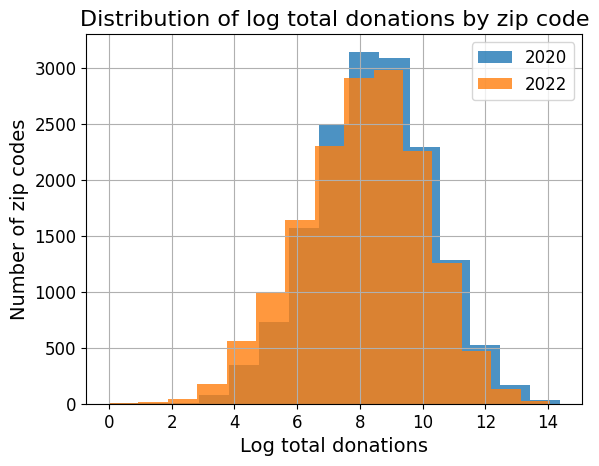

In [10]:
zip_data_both['LOG_TRANSACTION_AMT_2020'] = np.log(zip_data_both['TRANSACTION_AMT_2020'] + 1)
zip_data_both['LOG_TRANSACTION_AMT_2022'] = np.log(zip_data_both['TRANSACTION_AMT_2022'] + 1)

plt.rcParams.update({
    "font.size":        14,   # base size — scales most things
    "axes.titlesize":   16,   # chart title
    "axes.labelsize":   14,   # x/y axis labels
    "xtick.labelsize":  12,   # x tick labels (the model names)
    "ytick.labelsize":  12,   # y tick values
    "legend.fontsize":  12,   # T0/T1/T2/T3 legend
})

fig, ax = plt.subplots()
ax.set_title('Distribution of log total donations by zip code')
ax.set_ylabel('Number of zip codes')
ax.set_xlabel('Log total donations')
ax.grid()
ax = plt.hist(zip_data_both['LOG_TRANSACTION_AMT_2020'], alpha=0.8, bins=15, label='2020')
ax = plt.hist(zip_data_both['LOG_TRANSACTION_AMT_2022'], alpha=0.8, bins=15, label='2022')
plt.legend()
plt.savefig('donations_distribution.pdf')
plt.show()

# Semivariogram

Zips available for semivariogram: 15776
Computing empirical variograms...


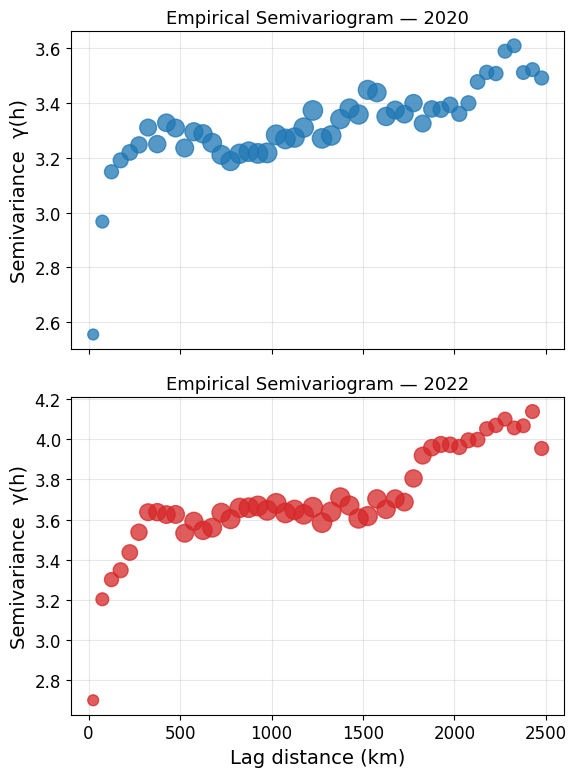

In [11]:
from scipy.spatial.distance import cdist

# zip_data_both has no lat/lon — get per-ZIP centroids from individual records
zip_latlon = (
    data['2020']
    .groupby('ZIP_CODE')[['LAT', 'LON']]
    .mean()
    .reset_index()
)

df_sv = zip_data_both[['ZIP_CODE', 'LOG_TRANSACTION_AMT_2020', 'LOG_TRANSACTION_AMT_2022']].merge(
    zip_latlon, on='ZIP_CODE', how='inner'
).dropna()

print(f'Zips available for semivariogram: {len(df_sv)}')

# ── Sample for computational tractability ────────────────────────────────────
rng = np.random.default_rng(42)
df_s = df_sv.sample(n=5000, random_state=1).reset_index(drop=True)

# (lat, lon) → approximate km
lat0 = np.radians(df_s['LAT'].mean())
x_km = df_s['LON'].values * 111.0 * np.cos(lat0)
y_km = df_s['LAT'].values * 111.0

# ── Empirical semivariogram (binned) ─────────────────────────────────────────
def empirical_variogram(x, y, z, n_bins=50, max_lag_frac=0.5):
    D = cdist(np.column_stack([x, y]), np.column_stack([x, y]))
    sq = 0.5 * (z[:, None] - z[None, :]) ** 2

    max_lag = max_lag_frac * D.max()
    bins = np.linspace(0, max_lag, n_bins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    gamma = []
    counts = []

    for k in range(n_bins):
        mask = (D >= bins[k]) & (D < bins[k+1]) & (D > 0)
        gamma.append(sq[mask].mean())
        counts.append(mask.sum())

    return centers, np.array(gamma), np.array(counts)

print('Computing empirical variograms...')
h_2020, g_2020, n_2020 = empirical_variogram(
    x_km, y_km, df_s['LOG_TRANSACTION_AMT_2020'].values
)

h_2022, g_2022, n_2022 = empirical_variogram(
    x_km, y_km, df_s['LOG_TRANSACTION_AMT_2022'].values
)

plt.rcParams.update({
    "font.size":        14,   # base size — scales most things
    "axes.titlesize":   16,   # chart title
    "axes.labelsize":   14,   # x/y axis labels
    "xtick.labelsize":  12,   # x tick labels (the model names)
    "ytick.labelsize":  12,   # y tick values
    "legend.fontsize":  12,   # T0/T1/T2/T3 legend
})

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

for ax, h, g, n, year, color in [
    (axes[0], h_2020, g_2020, n_2020, '2020', '#1f77b4'),
    (axes[1], h_2022, g_2022, n_2022, '2022', '#d62728'),
]:
    sizes = 20 + 180 * (n / n.max())

    ax.scatter(h, g, color=color, s=sizes, alpha=0.75, zorder=3)
    ax.set_title(f'Empirical Semivariogram — {year}', fontsize=13)
    ax.set_ylabel('Semivariance  γ(h)')
    ax.grid(alpha=0.3)
axes[1].set_xlabel('Lag distance (km)')

plt.tight_layout()
plt.savefig('semivariogram.pdf', bbox_inches='tight')
plt.show()

Computing log-binned empirical variograms...


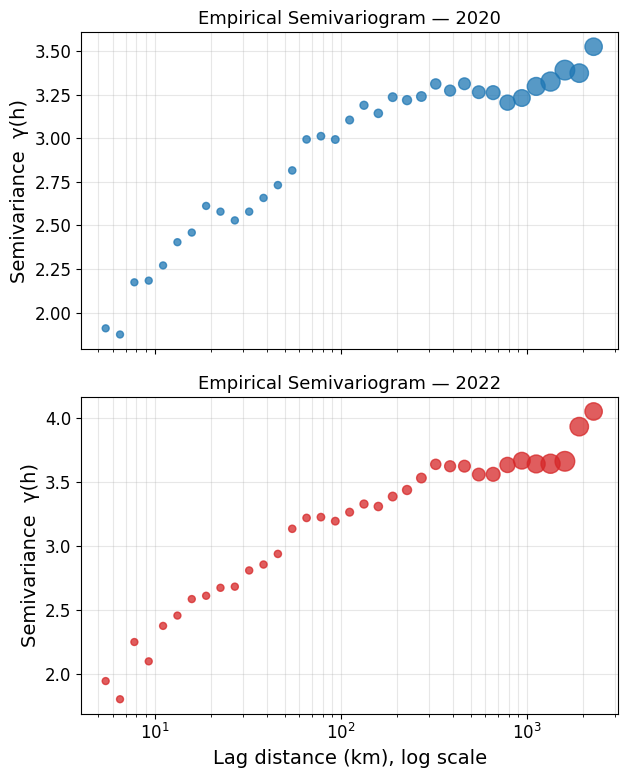

,lag_center_km,bin_left_km,bin_right_km,N_pairs
0,5.464260,5.000000,5.971627,496
1,6.526104,5.971627,7.132065,740
2,7.794291,7.132065,8.518006,980
3,9.308919,8.518006,10.173271,1368
4,11.117878,10.173271,12.150195,1828
5,13.278364,12.150195,14.511286,2458
6,15.858686,14.511286,17.331196,3145
7,18.940431,17.331196,20.699087,4026
8,22.621037,20.699087,24.721444,5270
9,27.016877,24.721444,29.525447,6388


In [12]:
# ── Empirical semivariogram with log-spaced distance bins ────────────────────

def empirical_variogram_logbins(x, y, z, n_bins=50, min_lag=5, max_lag_frac=0.5):

    coords = np.column_stack([x, y])

    D = cdist(coords, coords)

    sq = 0.5 * (z[:, None] - z[None, :]) ** 2

    upper = np.triu(np.ones_like(D, dtype=bool), k=1)

    max_lag = max_lag_frac * D.max()

    bins = np.geomspace(min_lag, max_lag, n_bins + 1)

    centers = np.sqrt(bins[:-1] * bins[1:])

    gamma = []

    counts = []

    for k in range(n_bins):

        mask = (D >= bins[k]) & (D < bins[k + 1]) & upper

        counts.append(mask.sum())

        gamma.append(np.nan if mask.sum() == 0 else sq[mask].mean())

    return centers, np.array(gamma), np.array(counts), bins

print('Computing log-binned empirical variograms...')

h_2020, g_2020, n_2020, bins = empirical_variogram_logbins(

    x_km, y_km, df_s['LOG_TRANSACTION_AMT_2020'].values,

    n_bins=35,

    min_lag=5,

    max_lag_frac=0.5

)

h_2022, g_2022, n_2022, _ = empirical_variogram_logbins(

    x_km, y_km, df_s['LOG_TRANSACTION_AMT_2022'].values,

    n_bins=35,

    min_lag=5,

    max_lag_frac=0.5

)

# ── Plot ─────────────────────────────────────────────────────────────────────

plt.rcParams.update({

    "font.size": 14,

    "axes.titlesize": 16,

    "axes.labelsize": 14,

    "xtick.labelsize": 12,

    "ytick.labelsize": 12,

    "legend.fontsize": 12,

})

fig, axes = plt.subplots(2, 1, figsize=(6.5, 8), sharex=True)

for ax, h, g, n, year, color in [

    (axes[0], h_2020, g_2020, n_2020, '2020', '#1f77b4'),

    (axes[1], h_2022, g_2022, n_2022, '2022', '#d62728'),

]:

    valid = np.isfinite(g) & (n > 0)

    sizes = 25 + 175 * (n[valid] / n[valid].max())

    ax.scatter(h[valid], g[valid], s=sizes, color=color, alpha=0.75, zorder=3)

    ax.set_xscale('log')

    ax.set_title(f'Empirical Semivariogram — {year}', fontsize=13)

    ax.set_ylabel('Semivariance  γ(h)')

    ax.grid(alpha=0.3, which='both')

axes[1].set_xlabel('Lag distance (km), log scale')

plt.tight_layout()

plt.savefig('semivariogram_logbins.pdf', bbox_inches='tight')

plt.show()

# Optional: inspect bin counts

bin_counts = pd.DataFrame({

    'lag_center_km': h_2020,

    'bin_left_km': bins[:-1],

    'bin_right_km': bins[1:],

    'N_pairs': n_2020,

})

display(bin_counts)

In [ ]:
# ── Save full-US model-ready dataset ─────────────────────────────────────────
zip_to_state = (
    data['2020']
    .dropna(subset=['STATE'])
    .groupby('ZIP_CODE')['STATE']
    .agg(lambda x: x.mode().iloc[0])
    .reset_index()
    .rename(columns={'STATE': 'state'})
)

# Bring in the raw election flags (election_2020, election_2022) alongside election_diff
elec_flags = elec[['ZIP_CODE', 'election_2020', 'election_2022', 'election_diff']]

zip_data_full = (
    df_sv
    .merge(
        zip_data_both[[
            'ZIP_CODE',
            'prop_college_degree_or_higher_18plus',
            'log_income',
            'log_population',
            'log_contrib_2020',
            'log_contrib_2022',
        ]],
        on='ZIP_CODE',
        how='inner',
    )
    .merge(elec_flags, on='ZIP_CODE', how='left')
    .merge(zip_to_state, on='ZIP_CODE', how='left')
    .rename(columns={'LAT': 'lat', 'LON': 'lon'})
    .dropna(subset=['state'])
)

print(f'Full-US model dataset: {len(zip_data_full)} ZIP codes, {zip_data_full["state"].nunique()} states')
print(zip_data_full.dtypes)
zip_data_full.to_csv('zip_data_full.csv', index=False)
print('Saved to final_paper/zip_data_full.csv')